In [1]:
%pip install -q ultralytics nuscenes-devkit opencv-python matplotlib pandas pillow timm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from ultralytics import YOLO

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

In [3]:
# -------- USER CONFIG --------
DATAROOT = r"C:\Users\ceyyd\Downloads\v1.0-mini"
VERSION = "v1.0-mini"

# Use your actual YOLO model paths or pretrained names here
YOLO_N_PATH = "yolo26n.pt"   # or your local path
YOLO_S_PATH = "yolo26s.pt"   # or your local path

CAMERA_CHANNEL = "CAM_FRONT"
TARGET_CLASSES = ["car", "person"]   # COCO names in Ultralytics
CONF_THRES = 0.25

# Single frame selection
SCENE_INDEX = 0
SAMPLE_INDEX_IN_SCENE = 0   # first sample in the chosen scene

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("DATAROOT exists:", os.path.exists(DATAROOT))

DEVICE: cuda
DATAROOT exists: True


In [4]:
if not os.path.exists(DATAROOT):
    raise FileNotFoundError(f"DATAROOT does not exist: {DATAROOT}")

print("Dataset root found.")

Dataset root found.


In [5]:
def load_image_rgb(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image path not found: {image_path}")
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"cv2 could not read image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

In [6]:
def get_scene_sample_token(nusc, scene_index=0, sample_index_in_scene=0):
    scene = nusc.scene[scene_index]
    sample_token = scene["first_sample_token"]
    sample = nusc.get("sample", sample_token)

    for _ in range(sample_index_in_scene):
        if sample["next"] == "":
            break
        sample = nusc.get("sample", sample["next"])

    return sample["token"]

In [7]:
def get_cam_front_data(nusc, sample_token, camera_channel="CAM_FRONT"):
    sample = nusc.get("sample", sample_token)
    cam_token = sample["data"][camera_channel]
    sd_record = nusc.get("sample_data", cam_token)
    cs_record = nusc.get("calibrated_sensor", sd_record["calibrated_sensor_token"])
    ep_record = nusc.get("ego_pose", sd_record["ego_pose_token"])

    image_path = os.path.join(nusc.dataroot, sd_record["filename"])
    K = np.array(cs_record["camera_intrinsic"], dtype=np.float64)

    return {
        "sample": sample,
        "sd_record": sd_record,
        "cs_record": cs_record,
        "ep_record": ep_record,
        "image_path": image_path,
        "K": K
    }

In [8]:
def quaternion_to_rotmat(q):
    return Quaternion(q).rotation_matrix

In [9]:
def global_to_ego(point_global, ego_translation, ego_rotation):
    """
    point_global: (3,)
    ego_translation: [x,y,z]
    ego_rotation: quaternion list [w,x,y,z]
    returns point in ego frame
    """
    R_ego = quaternion_to_rotmat(ego_rotation)
    t_ego = np.array(ego_translation, dtype=np.float64)
    point_global = np.array(point_global, dtype=np.float64)

    point_ego = R_ego.T @ (point_global - t_ego)
    return point_ego

In [10]:
def ego_to_camera(point_ego, cam_translation, cam_rotation):
    """
    point_ego: (3,)
    cam_translation: camera position in ego frame
    cam_rotation: camera rotation wrt ego
    returns point in camera frame
    """
    R_cam = quaternion_to_rotmat(cam_rotation)
    t_cam = np.array(cam_translation, dtype=np.float64)
    point_ego = np.array(point_ego, dtype=np.float64)

    point_cam = R_cam.T @ (point_ego - t_cam)
    return point_cam

In [11]:
def camera_to_ego(point_cam, cam_translation, cam_rotation):
    """
    inverse of ego_to_camera
    """
    R_cam = quaternion_to_rotmat(cam_rotation)
    t_cam = np.array(cam_translation, dtype=np.float64)
    point_cam = np.array(point_cam, dtype=np.float64)

    point_ego = R_cam @ point_cam + t_cam
    return point_ego

In [12]:
def project_camera_point_to_image(point_cam, K):
    """
    point_cam: [Xc, Yc, Zc] in camera frame
    Returns (u, v, z_cam), or None if behind camera
    """
    Xc, Yc, Zc = point_cam
    if Zc <= 1e-6:
        return None

    uvw = K @ np.array([Xc, Yc, Zc], dtype=np.float64)
    u = uvw[0] / uvw[2]
    v = uvw[1] / uvw[2]
    return float(u), float(v), float(Zc)

In [13]:
def coco_name_to_thesis_name(name):
    # Ultralytics COCO uses "person", nuScenes uses "vehicle.car", "human.pedestrian.*"
    if name == "person":
        return "pedestrian"
    elif name == "car":
        return "car"
    return None

In [14]:
def nuscenes_category_to_simple(category_name):
    if category_name == "vehicle.car":
        return "car"
    if category_name.startswith("human.pedestrian"):
        return "pedestrian"
    return None

In [15]:
def run_yolo_on_image(model, image_rgb, conf_thres=0.25):
    results = model.predict(source=image_rgb, conf=conf_thres, verbose=False, device=DEVICE)
    r = results[0]

    detections = []
    names = r.names

    if r.boxes is None or len(r.boxes) == 0:
        return detections

    xyxy = r.boxes.xyxy.cpu().numpy()
    cls = r.boxes.cls.cpu().numpy().astype(int)
    conf = r.boxes.conf.cpu().numpy()

    for box, c, score in zip(xyxy, cls, conf):
        x1, y1, x2, y2 = box
        class_name = names[int(c)]
        simple_name = coco_name_to_thesis_name(class_name)

        if simple_name not in ["car", "pedestrian"]:
            continue

        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0

        detections.append({
            "class_name": simple_name,
            "score": float(score),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "cx": float(cx),
            "cy": float(cy)
        })

    return detections

In [16]:
def extract_gt_for_cam_front(nusc, sample, cs_record, ep_record, K, image_width, image_height):
    """
    For each sample annotation:
    global -> ego -> camera -> image plane
    Keep only car / pedestrian and only points visible in image and in front of camera.
    """
    gt_list = []

    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)
        simple_cls = nuscenes_category_to_simple(ann["category_name"])
        if simple_cls not in ["car", "pedestrian"]:
            continue

        point_global = np.array(ann["translation"], dtype=np.float64)

        point_ego = global_to_ego(
            point_global,
            ego_translation=ep_record["translation"],
            ego_rotation=ep_record["rotation"]
        )

        point_cam = ego_to_camera(
            point_ego,
            cam_translation=cs_record["translation"],
            cam_rotation=cs_record["rotation"]
        )

        proj = project_camera_point_to_image(point_cam, K)
        if proj is None:
            continue

        u, v, z_cam = proj

        if not (0 <= u < image_width and 0 <= v < image_height):
            continue

        gt_list.append({
            "ann_token": ann_token,
            "class_name": simple_cls,
            "global_xyz": point_global,
            "ego_xyz": point_ego,
            "cam_xyz": point_cam,
            "u": float(u),
            "v": float(v),
            "z_cam": float(z_cam)
        })

    return gt_list

In [17]:
def match_detections_to_gt(detections, gt_list, max_pixel_dist=80):
    """
    Greedy class-consistent nearest matching using pixel center distance
    """
    matches = []
    used_gt = set()

    for det_idx, det in enumerate(detections):
        best_gt_idx = None
        best_dist = float("inf")

        for gt_idx, gt in enumerate(gt_list):
            if gt_idx in used_gt:
                continue
            if det["class_name"] != gt["class_name"]:
                continue

            dist = math.sqrt((det["cx"] - gt["u"])**2 + (det["cy"] - gt["v"])**2)
            if dist < best_dist:
                best_dist = dist
                best_gt_idx = gt_idx

        if best_gt_idx is not None and best_dist <= max_pixel_dist:
            used_gt.add(best_gt_idx)
            matches.append({
                "det_idx": det_idx,
                "gt_idx": best_gt_idx,
                "class_name": det["class_name"],
                "pixel_dist": float(best_dist)
            })

    return matches

In [18]:
def show_image_with_points(image_rgb, detections=None, gt_list=None, title=""):
    img = image_rgb.copy()
    plt.figure(figsize=(14, 8))
    plt.imshow(img)

    if gt_list is not None:
        for gt in gt_list:
            plt.scatter(gt["u"], gt["v"], c="lime", s=60, marker="x")
            plt.text(gt["u"] + 5, gt["v"] + 5, f'GT:{gt["class_name"]}', color="lime", fontsize=9)

    if detections is not None:
        for det in detections:
            x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2)
            plt.gca().add_patch(rect)
            plt.scatter(det["cx"], det["cy"], c="yellow", s=30)
            plt.text(x1, y1 - 5, f'DET:{det["class_name"]}', color="red", fontsize=9)

    plt.title(title)
    plt.axis("off")
    plt.show()

In [19]:
def load_midas_model():
    # MiDaS via torch hub
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
    midas.to(DEVICE)
    midas.eval()

    transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = transforms.small_transform

    return midas, transform

In [20]:
def predict_midas_depth(midas, transform, image_rgb):
    """
    Returns a depth-like map resized to original image size.
    Note: MiDaS output is relative, not metric.
    """
    input_batch = transform(image_rgb).to(DEVICE)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=image_rgb.shape[:2],
            mode="bicubic",
            align_corners=False
        ).squeeze()

    depth_rel = prediction.cpu().numpy()

    # Convert inverse-like output to positive depth-like quantity
    # This avoids sign/range headaches in later scaling.
    depth_rel = depth_rel - depth_rel.min() + 1e-6

    return depth_rel

In [21]:
def sample_depth_at_pixel(depth_map, u, v):
    h, w = depth_map.shape
    u_i = int(np.clip(round(u), 0, w - 1))
    v_i = int(np.clip(round(v), 0, h - 1))
    return float(depth_map[v_i, u_i])

In [22]:
def estimate_scale_factor(matches, detections, gt_list, depth_map):
    """
    Scale relative depth to metric camera Z using matched GT.
    scale = median(gt_z_cam / rel_depth_at_det_center)
    """
    ratios = []

    for m in matches:
        det = detections[m["det_idx"]]
        gt = gt_list[m["gt_idx"]]

        d_rel = sample_depth_at_pixel(depth_map, det["cx"], det["cy"])
        z_gt = gt["z_cam"]

        if d_rel > 1e-6 and z_gt > 1e-6:
            ratios.append(z_gt / d_rel)

    if len(ratios) == 0:
        return None

    return float(np.median(ratios))

In [23]:
def pixel_to_camera_xyz(u, v, z, K):
    """
    Back-project pixel with metric depth z into camera frame
    """
    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    X = (u - cx) * z / fx
    Y = (v - cy) * z / fy
    Z = z

    return np.array([X, Y, Z], dtype=np.float64)

In [24]:
def compute_localization_results(matches, detections, gt_list, depth_map, scale_factor, K, cs_record):
    rows = []

    if scale_factor is None:
        return pd.DataFrame()

    for m in matches:
        det = detections[m["det_idx"]]
        gt = gt_list[m["gt_idx"]]

        d_rel = sample_depth_at_pixel(depth_map, det["cx"], det["cy"])
        z_pred_cam = scale_factor * d_rel

        pred_cam_xyz = pixel_to_camera_xyz(det["cx"], det["cy"], z_pred_cam, K)
        pred_ego_xyz = camera_to_ego(
            pred_cam_xyz,
            cam_translation=cs_record["translation"],
            cam_rotation=cs_record["rotation"]
        )

        gt_ego_xyz = gt["ego_xyz"]

        # Thesis target says compare X,Y in ego frame
        err_xy = np.linalg.norm(pred_ego_xyz[:2] - gt_ego_xyz[:2])

        # optional full 3D error too
        err_xyz = np.linalg.norm(pred_ego_xyz - gt_ego_xyz)

        rows.append({
            "class_name": det["class_name"],
            "det_cx": det["cx"],
            "det_cy": det["cy"],
            "gt_u": gt["u"],
            "gt_v": gt["v"],
            "pixel_dist": m["pixel_dist"],
            "gt_ego_x": gt_ego_xyz[0],
            "gt_ego_y": gt_ego_xyz[1],
            "gt_ego_z": gt_ego_xyz[2],
            "pred_ego_x": pred_ego_xyz[0],
            "pred_ego_y": pred_ego_xyz[1],
            "pred_ego_z": pred_ego_xyz[2],
            "gt_z_cam": gt["z_cam"],
            "pred_z_cam": z_pred_cam,
            "loc_error_xy": err_xy,
            "loc_error_xyz": err_xyz
        })

    return pd.DataFrame(rows)

In [25]:
def summarize_results(df, model_name):
    if df.empty:
        return pd.DataFrame([{
            "model": model_name,
            "num_matches": 0,
            "mean_loc_error_xy": np.nan,
            "median_loc_error_xy": np.nan,
            "mean_loc_error_xyz": np.nan,
            "median_loc_error_xyz": np.nan
        }])

    return pd.DataFrame([{
        "model": model_name,
        "num_matches": len(df),
        "mean_loc_error_xy": df["loc_error_xy"].mean(),
        "median_loc_error_xy": df["loc_error_xy"].median(),
        "mean_loc_error_xyz": df["loc_error_xyz"].mean(),
        "median_loc_error_xyz": df["loc_error_xyz"].median()
    }])

In [26]:
nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.342 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [27]:
sample_token = get_scene_sample_token(
    nusc,
    scene_index=SCENE_INDEX,
    sample_index_in_scene=SAMPLE_INDEX_IN_SCENE
)

cam_data = get_cam_front_data(
    nusc,
    sample_token=sample_token,
    camera_channel=CAMERA_CHANNEL
)

sample = cam_data["sample"]
sd_record = cam_data["sd_record"]
cs_record = cam_data["cs_record"]
ep_record = cam_data["ep_record"]
image_path = cam_data["image_path"]
K = cam_data["K"]

print("Sample token:", sample_token)
print("Image path:", image_path)
print("Image exists:", os.path.exists(image_path))
print("Camera intrinsic K:\n", K)

Sample token: ca9a282c9e77460f8360f564131a8af5
Image path: C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Image exists: True
Camera intrinsic K:
 [[     1266.4           0      816.27]
 [          0      1266.4      491.51]
 [          0           0           1]]


Image shape: (900, 1600, 3)


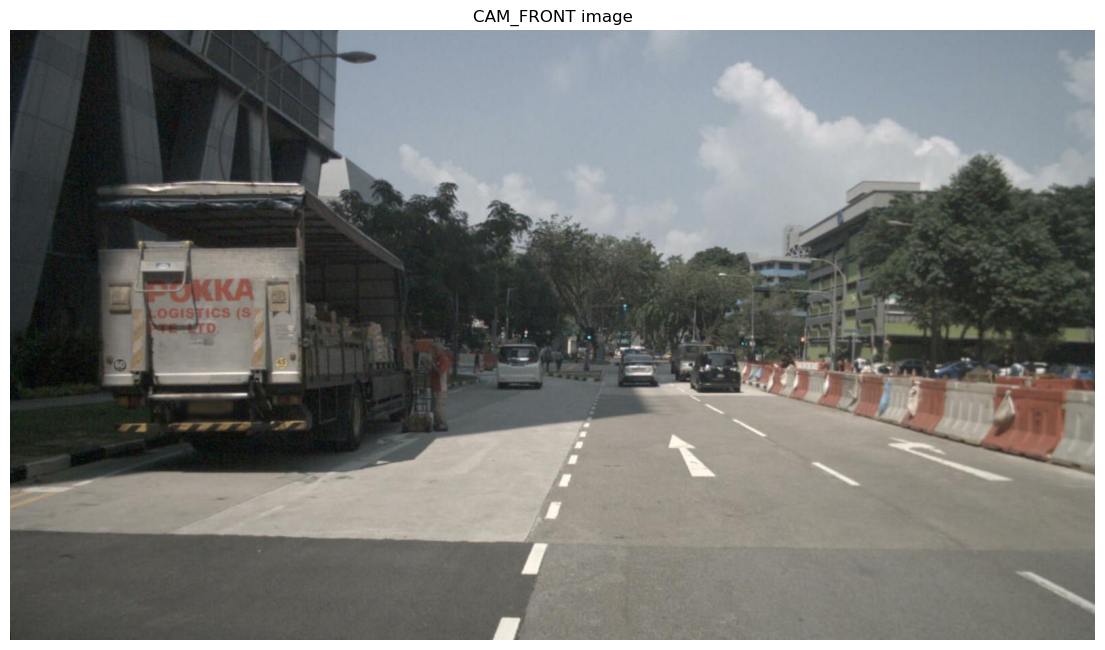

In [28]:
img_rgb = load_image_rgb(image_path)
img_h, img_w = img_rgb.shape[:2]

print("Image shape:", img_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(img_rgb)
plt.title("CAM_FRONT image")
plt.axis("off")
plt.show()

In [29]:
model_n = YOLO(YOLO_N_PATH)
model_s = YOLO(YOLO_S_PATH)

print("YOLO models loaded.")

YOLO models loaded.


In [30]:
detections_n = run_yolo_on_image(model_n, img_rgb, conf_thres=CONF_THRES)
detections_s = run_yolo_on_image(model_s, img_rgb, conf_thres=CONF_THRES)

print("YOLO26n detections:", len(detections_n))
print("YOLO26s detections:", len(detections_s))

pd.DataFrame(detections_n).head()

YOLO26n detections: 1
YOLO26s detections: 2


,class_name,score,x1,y1,x2,y2,cx,cy
0,car,0.355136,898.787903,476.80072,954.982605,528.669434,926.885254,502.735077


In [31]:
pd.DataFrame(detections_s).head()

,class_name,score,x1,y1,x2,y2,cx,cy
0,car,0.735420,896.978088,492.805939,956.099976,526.816956,926.539062,509.811462
1,pedestrian,0.250773,595.416504,444.709534,651.841492,594.918762,623.629028,519.814148


In [32]:
gt_list = extract_gt_for_cam_front(
    nusc=nusc,
    sample=sample,
    cs_record=cs_record,
    ep_record=ep_record,
    K=K,
    image_width=img_w,
    image_height=img_h
)

print("Visible GT objects in CAM_FRONT:", len(gt_list))
pd.DataFrame(gt_list)[["class_name", "u", "v", "z_cam"]].head()

Visible GT objects in CAM_FRONT: 24


,class_name,u,v,z_cam
0,pedestrian,1216.175326,495.660725,59.024867
1,pedestrian,1569.389342,511.009738,35.549851
2,car,1562.051438,506.140229,63.831901
3,pedestrian,1505.140879,509.316586,37.812038
4,pedestrian,689.965230,490.174849,58.955847


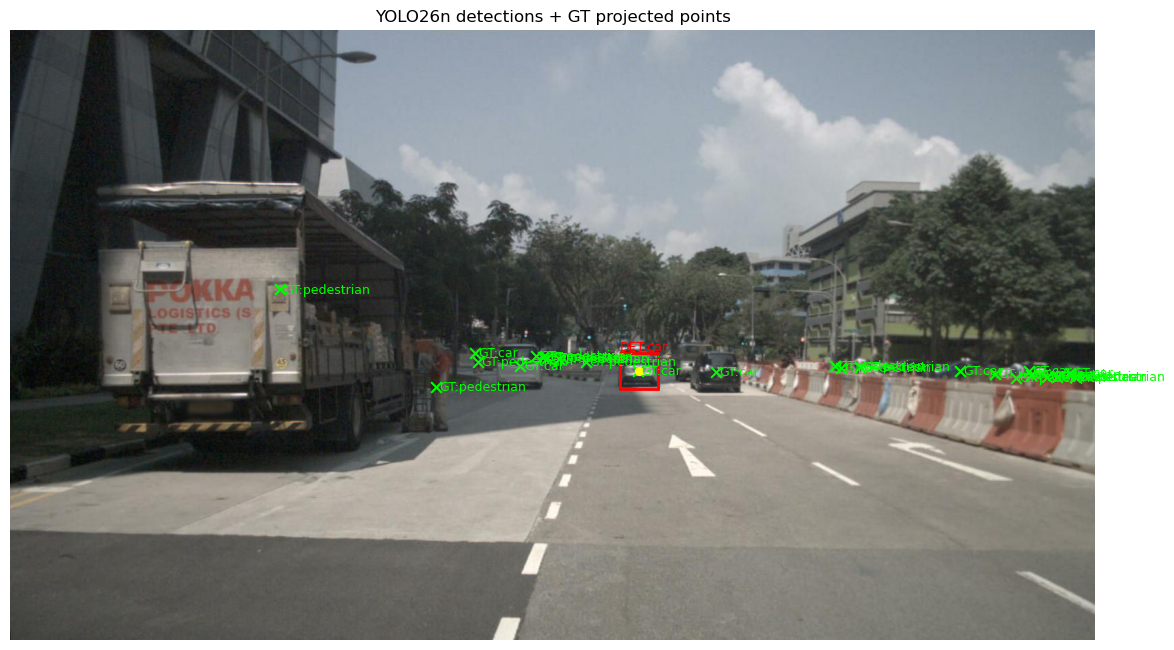

In [33]:
show_image_with_points(
    img_rgb,
    detections=detections_n,
    gt_list=gt_list,
    title="YOLO26n detections + GT projected points"
)

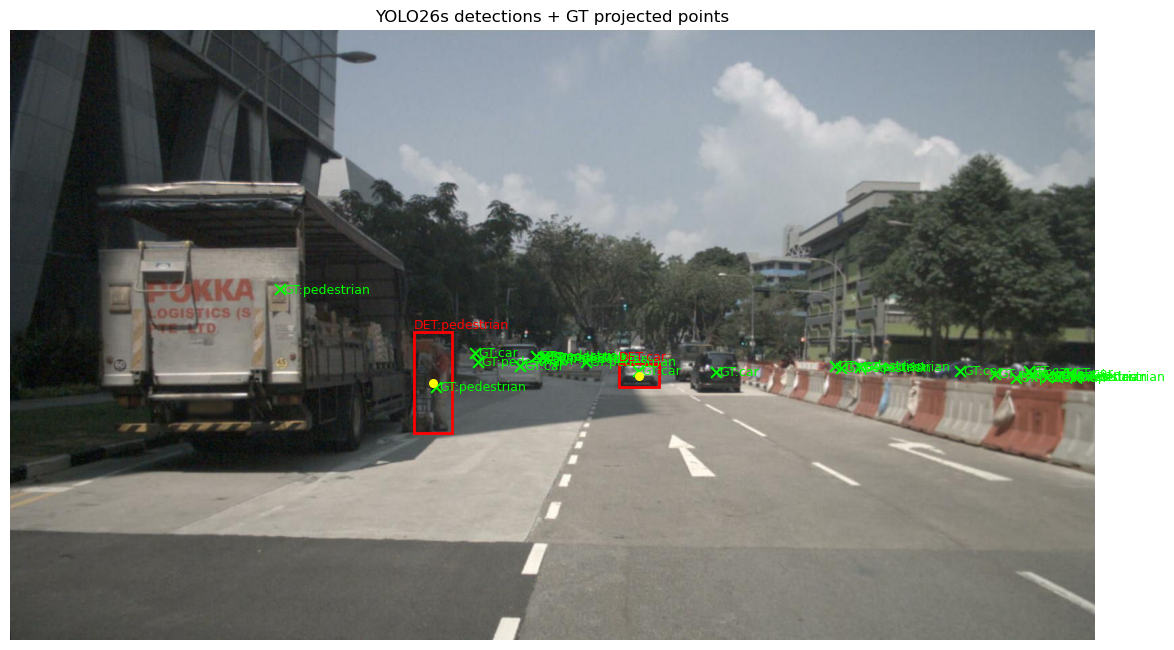

In [34]:
show_image_with_points(
    img_rgb,
    detections=detections_s,
    gt_list=gt_list,
    title="YOLO26s detections + GT projected points"
)

In [35]:
matches_n = match_detections_to_gt(detections_n, gt_list, max_pixel_dist=80)
matches_s = match_detections_to_gt(detections_s, gt_list, max_pixel_dist=80)

print("Matches n:", len(matches_n))
print("Matches s:", len(matches_s))

pd.DataFrame(matches_n)

Matches n: 1
Matches s: 2


,det_idx,gt_idx,class_name,pixel_dist
0,0,12,car,1.025104


In [36]:
pd.DataFrame(matches_s)

,det_idx,gt_idx,class_name,pixel_dist
0,0,12,car,7.592312
1,1,22,pedestrian,7.939271


In [37]:
midas, midas_transform = load_midas_model()
print("MiDaS loaded.")

Using cache found in C:\Users\ceyyd/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\ceyyd/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


MiDaS loaded.


Using cache found in C:\Users\ceyyd/.cache\torch\hub\intel-isl_MiDaS_master


Depth map shape: (900, 1600)
Depth min/max: 1e-06 690.7739


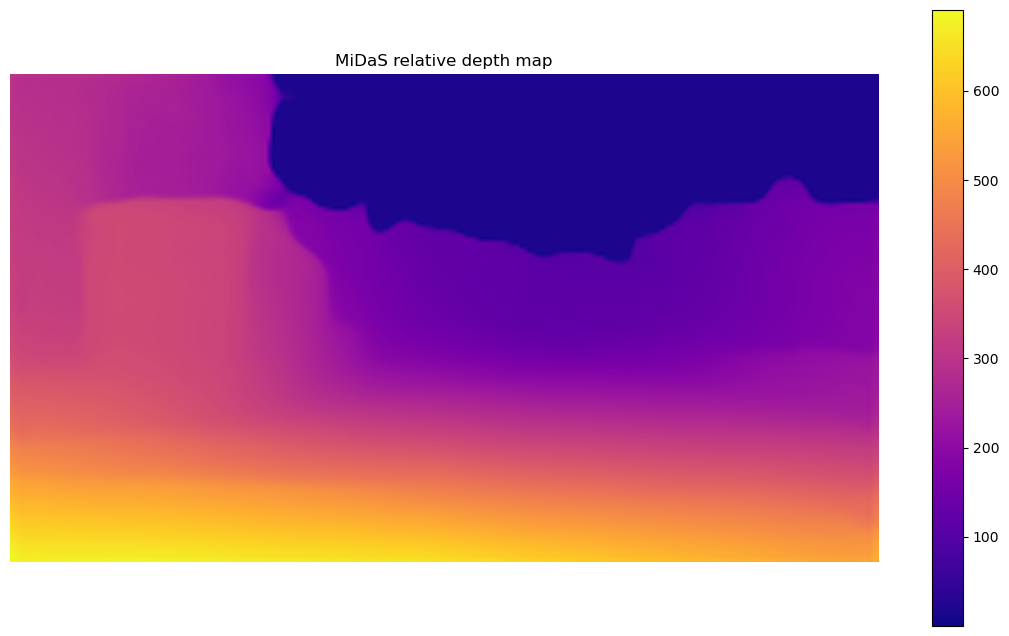

In [38]:
depth_rel = predict_midas_depth(midas, midas_transform, img_rgb)

print("Depth map shape:", depth_rel.shape)
print("Depth min/max:", depth_rel.min(), depth_rel.max())

plt.figure(figsize=(14, 8))
plt.imshow(depth_rel, cmap="plasma")
plt.title("MiDaS relative depth map")
plt.axis("off")
plt.colorbar()
plt.show()

In [39]:
scale_n = estimate_scale_factor(matches_n, detections_n, gt_list, depth_rel)
scale_s = estimate_scale_factor(matches_s, detections_s, gt_list, depth_rel)

print("Scale factor for YOLO26n:", scale_n)
print("Scale factor for YOLO26s:", scale_s)

Scale factor for YOLO26n: 0.28088533372137303
Scale factor for YOLO26s: 0.17170373543891643


In [40]:
results_n = compute_localization_results(
    matches=matches_n,
    detections=detections_n,
    gt_list=gt_list,
    depth_map=depth_rel,
    scale_factor=scale_n,
    K=K,
    cs_record=cs_record
)

results_s = compute_localization_results(
    matches=matches_s,
    detections=detections_s,
    gt_list=gt_list,
    depth_map=depth_rel,
    scale_factor=scale_s,
    K=K,
    cs_record=cs_record
)

print("Results n rows:", len(results_n))
print("Results s rows:", len(results_s))

Results n rows: 1
Results s rows: 2


In [41]:
results_n

,class_name,det_cx,det_cy,gt_u,gt_v,pixel_dist,gt_ego_x,gt_ego_y,gt_ego_z,pred_ego_x,pred_ego_y,pred_ego_z,gt_z_cam,pred_z_cam,loc_error_xy,loc_error_xyz
0,car,926.885254,502.735077,925.988084,502.239169,1.025104,41.611713,-3.214088,0.950607,41.611785,-3.242363,0.935008,39.894456,39.894456,0.028275,0.032293


In [42]:
results_s

,class_name,det_cx,det_cy,gt_u,gt_v,pixel_dist,gt_ego_x,gt_ego_y,gt_ego_z,pred_ego_x,pred_ego_y,pred_ego_z,gt_z_cam,pred_z_cam,loc_error_xy,loc_error_xyz
0,car,926.539062,509.811462,925.988084,502.239169,7.592312,41.611713,-3.214088,0.950607,26.996293,-2.042438,1.004616,39.894456,25.285856,14.662307,14.662406
1,pedestrian,623.629028,519.814148,627.575052,526.703337,7.939271,18.107358,2.555870,0.959900,40.555293,6.152355,0.417424,16.423576,38.894281,22.734214,22.740686


In [43]:
summary_n = summarize_results(results_n, "YOLO26n")
summary_s = summarize_results(results_s, "YOLO26s")

comparison_df = pd.concat([summary_n, summary_s], ignore_index=True)
comparison_df

,model,num_matches,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz
0,YOLO26n,1,0.028275,0.028275,0.032293,0.032293
1,YOLO26s,2,18.698261,18.698261,18.701546,18.701546


In [44]:
results_n.to_csv("results_yolo26n_single_frame.csv", index=False)
results_s.to_csv("results_yolo26s_single_frame.csv", index=False)
comparison_df.to_csv("comparison_single_frame.csv", index=False)

print("Saved CSV files.")

Saved CSV files.


In [45]:
print("Debug summary")
print("-" * 50)
print("Image path:", image_path)
print("Image shape:", img_rgb.shape)
print("Detections n:", len(detections_n))
print("Detections s:", len(detections_s))
print("GT visible:", len(gt_list))
print("Matches n:", len(matches_n))
print("Matches s:", len(matches_s))
print("Scale n:", scale_n)
print("Scale s:", scale_s)

if len(gt_list) > 0:
    print("\nFirst GT example:")
    print(gt_list[0])

if len(detections_n) > 0:
    print("\nFirst YOLO26n detection:")
    print(detections_n[0])

if len(matches_n) > 0:
    print("\nFirst match n:")
    print(matches_n[0])

Debug summary
--------------------------------------------------
Image path: C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Image shape: (900, 1600, 3)
Detections n: 1
Detections s: 2
GT visible: 24
Matches n: 1
Matches s: 2
Scale n: 0.28088533372137303
Scale s: 0.17170373543891643

First GT example:
{'ann_token': 'ef63a697930c4b20a6b9791f423351da', 'class_name': 'pedestrian', 'global_xyz': array([     373.26,      1130.4,         0.8]), 'ego_xyz': array([     60.829,     -18.287,     0.99939]), 'cam_xyz': array([     18.639,     0.19359,      59.025]), 'u': 1216.1753257349687, 'v': 495.6607253815475, 'z_cam': 59.024867320654835}

First YOLO26n detection:
{'class_name': 'car', 'score': 0.35513558983802795, 'x1': 898.7879028320312, 'y1': 476.80072021484375, 'x2': 954.9826049804688, 'y2': 528.66943359375, 'cx': 926.88525390625, 'cy': 502.7350769042969}

First match n:
{'det_idx': 0, 'gt_idx': 12, 'class_name': 'car', 'p

In [46]:
import time

In [47]:
def process_one_sample(
    nusc,
    sample_token,
    model,
    model_name,
    midas,
    midas_transform,
    camera_channel="CAM_FRONT",
    conf_thres=0.25,
    max_pixel_dist=80,
    visualize=False
):
    # ----------------------------
    # Load camera/frame info
    # ----------------------------
    cam_data = get_cam_front_data(
        nusc,
        sample_token=sample_token,
        camera_channel=camera_channel
    )

    sample = cam_data["sample"]
    sd_record = cam_data["sd_record"]
    cs_record = cam_data["cs_record"]
    ep_record = cam_data["ep_record"]
    image_path = cam_data["image_path"]
    K = cam_data["K"]

    img_rgb = load_image_rgb(image_path)
    img_h, img_w = img_rgb.shape[:2]

    # ----------------------------
    # YOLO inference timing
    # ----------------------------
    t0 = time.perf_counter()
    detections = run_yolo_on_image(model, img_rgb, conf_thres=conf_thres)
    t1 = time.perf_counter()
    yolo_time_sec = t1 - t0

    # ----------------------------
    # GT extraction
    # ----------------------------
    gt_list = extract_gt_for_cam_front(
        nusc=nusc,
        sample=sample,
        cs_record=cs_record,
        ep_record=ep_record,
        K=K,
        image_width=img_w,
        image_height=img_h
    )

    # ----------------------------
    # Matching
    # ----------------------------
    matches = match_detections_to_gt(
        detections=detections,
        gt_list=gt_list,
        max_pixel_dist=max_pixel_dist
    )

    # ----------------------------
    # MiDaS depth timing
    # ----------------------------
    t2 = time.perf_counter()
    depth_rel = predict_midas_depth(midas, midas_transform, img_rgb)
    t3 = time.perf_counter()
    midas_time_sec = t3 - t2

    # ----------------------------
    # Scale factor
    # ----------------------------
    scale_factor = estimate_scale_factor(matches, detections, gt_list, depth_rel)

    # ----------------------------
    # Localization results
    # ----------------------------
    results_df = compute_localization_results(
        matches=matches,
        detections=detections,
        gt_list=gt_list,
        depth_map=depth_rel,
        scale_factor=scale_factor,
        K=K,
        cs_record=cs_record
    )

    # Add metadata columns
    if not results_df.empty:
        results_df["model"] = model_name
        results_df["sample_token"] = sample_token
        results_df["scene_token"] = sample["scene_token"]
        results_df["image_path"] = image_path
        results_df["num_detections"] = len(detections)
        results_df["num_gt_visible"] = len(gt_list)
        results_df["num_matches"] = len(matches)
        results_df["scale_factor"] = scale_factor
        results_df["yolo_time_sec"] = yolo_time_sec
        results_df["midas_time_sec"] = midas_time_sec
        results_df["total_time_sec"] = yolo_time_sec + midas_time_sec

    # Summary row for this image
    summary_row = {
        "model": model_name,
        "sample_token": sample_token,
        "scene_token": sample["scene_token"],
        "image_path": image_path,
        "num_detections": len(detections),
        "num_gt_visible": len(gt_list),
        "num_matches": len(matches),
        "scale_factor": scale_factor,
        "yolo_time_sec": yolo_time_sec,
        "midas_time_sec": midas_time_sec,
        "total_time_sec": yolo_time_sec + midas_time_sec,
        "mean_loc_error_xy": results_df["loc_error_xy"].mean() if not results_df.empty else np.nan,
        "median_loc_error_xy": results_df["loc_error_xy"].median() if not results_df.empty else np.nan,
        "mean_loc_error_xyz": results_df["loc_error_xyz"].mean() if not results_df.empty else np.nan,
        "median_loc_error_xyz": results_df["loc_error_xyz"].median() if not results_df.empty else np.nan
    }

    if visualize:
        show_image_with_points(
            img_rgb,
            detections=detections,
            gt_list=gt_list,
            title=f"{model_name} | sample {sample_token[:8]}"
        )

    return results_df, summary_row

In [48]:
def get_all_sample_tokens_in_scene(nusc, scene_index=0):
    scene = nusc.scene[scene_index]
    sample_tokens = []

    current_token = scene["first_sample_token"]

    while current_token != "":
        sample_tokens.append(current_token)
        current_sample = nusc.get("sample", current_token)
        current_token = current_sample["next"]

    return sample_tokens

In [49]:
def process_scene(
    nusc,
    scene_index,
    model,
    model_name,
    midas,
    midas_transform,
    camera_channel="CAM_FRONT",
    conf_thres=0.25,
    max_pixel_dist=80,
    max_samples=None,
    verbose=True
):
    sample_tokens = get_all_sample_tokens_in_scene(nusc, scene_index=scene_index)

    if max_samples is not None:
        sample_tokens = sample_tokens[:max_samples]

    all_results = []
    all_summaries = []

    if verbose:
        print(f"Processing scene_index={scene_index} with {len(sample_tokens)} samples for {model_name}")

    for i, sample_token in enumerate(sample_tokens, start=1):
        try:
            results_df, summary_row = process_one_sample(
                nusc=nusc,
                sample_token=sample_token,
                model=model,
                model_name=model_name,
                midas=midas,
                midas_transform=midas_transform,
                camera_channel=camera_channel,
                conf_thres=conf_thres,
                max_pixel_dist=max_pixel_dist,
                visualize=False
            )

            if not results_df.empty:
                all_results.append(results_df)

            all_summaries.append(summary_row)

            if verbose:
                print(
                    f"[{i}/{len(sample_tokens)}] "
                    f"matches={summary_row['num_matches']} | "
                    f"mean_xy={summary_row['mean_loc_error_xy']} | "
                    f"time={summary_row['total_time_sec']:.3f}s"
                )

        except Exception as e:
            print(f"Error in sample {sample_token}: {e}")
            all_summaries.append({
                "model": model_name,
                "sample_token": sample_token,
                "scene_token": nusc.scene[scene_index]["token"],
                "image_path": None,
                "num_detections": np.nan,
                "num_gt_visible": np.nan,
                "num_matches": np.nan,
                "scale_factor": np.nan,
                "yolo_time_sec": np.nan,
                "midas_time_sec": np.nan,
                "total_time_sec": np.nan,
                "mean_loc_error_xy": np.nan,
                "median_loc_error_xy": np.nan,
                "mean_loc_error_xyz": np.nan,
                "median_loc_error_xyz": np.nan,
                "error_message": str(e)
            })

    results_scene_df = pd.concat(all_results, ignore_index=True) if len(all_results) > 0 else pd.DataFrame()
    summary_scene_df = pd.DataFrame(all_summaries)

    return results_scene_df, summary_scene_df

In [50]:
def summarize_scene_level(summary_df, model_name):
    valid = summary_df.dropna(subset=["num_matches"])

    if valid.empty:
        return pd.DataFrame([{
            "model": model_name,
            "num_images": 0,
            "total_matches": 0,
            "avg_matches_per_image": np.nan,
            "mean_loc_error_xy": np.nan,
            "median_loc_error_xy": np.nan,
            "mean_loc_error_xyz": np.nan,
            "median_loc_error_xyz": np.nan,
            "mean_yolo_time_sec": np.nan,
            "mean_midas_time_sec": np.nan,
            "mean_total_time_sec": np.nan,
            "fps_pipeline": np.nan
        }])

    return pd.DataFrame([{
        "model": model_name,
        "num_images": len(valid),
        "total_matches": valid["num_matches"].fillna(0).sum(),
        "avg_matches_per_image": valid["num_matches"].fillna(0).mean(),
        "mean_loc_error_xy": valid["mean_loc_error_xy"].mean(),
        "median_loc_error_xy": valid["median_loc_error_xy"].median(),
        "mean_loc_error_xyz": valid["mean_loc_error_xyz"].mean(),
        "median_loc_error_xyz": valid["median_loc_error_xyz"].median(),
        "mean_yolo_time_sec": valid["yolo_time_sec"].mean(),
        "mean_midas_time_sec": valid["midas_time_sec"].mean(),
        "mean_total_time_sec": valid["total_time_sec"].mean(),
        "fps_pipeline": 1.0 / valid["total_time_sec"].mean() if valid["total_time_sec"].mean() > 0 else np.nan
    }])

In [51]:
scene_index_test = 0
max_samples_test = 5

In [52]:
results_scene_n_test, summary_scene_n_test = process_scene(
    nusc=nusc,
    scene_index=scene_index_test,
    model=model_n,
    model_name="YOLO26n",
    midas=midas,
    midas_transform=midas_transform,
    camera_channel=CAMERA_CHANNEL,
    conf_thres=CONF_THRES,
    max_pixel_dist=80,
    max_samples=max_samples_test,
    verbose=True
)

Processing scene_index=0 with 5 samples for YOLO26n
[1/5] matches=1 | mean_xy=0.0282751822968951 | time=0.038s
[2/5] matches=2 | mean_xy=15.769881284255932 | time=0.035s
[3/5] matches=3 | mean_xy=29.574279610540486 | time=0.044s
[4/5] matches=3 | mean_xy=10.855419703822767 | time=0.034s
[5/5] matches=4 | mean_xy=23.022035677250855 | time=0.041s


In [53]:
results_scene_s_test, summary_scene_s_test = process_scene(
    nusc=nusc,
    scene_index=scene_index_test,
    model=model_s,
    model_name="YOLO26s",
    midas=midas,
    midas_transform=midas_transform,
    camera_channel=CAMERA_CHANNEL,
    conf_thres=CONF_THRES,
    max_pixel_dist=80,
    max_samples=max_samples_test,
    verbose=True
)

Processing scene_index=0 with 5 samples for YOLO26s
[1/5] matches=2 | mean_xy=18.698260530956116 | time=0.035s
[2/5] matches=4 | mean_xy=27.468212502678973 | time=0.034s
[3/5] matches=5 | mean_xy=36.74049328354014 | time=0.047s
[4/5] matches=4 | mean_xy=21.312589731737923 | time=0.036s
[5/5] matches=4 | mean_xy=23.362122281701826 | time=0.037s


In [54]:
summary_scene_n_test.head()

,model,sample_token,scene_token,image_path,num_detections,num_gt_visible,num_matches,scale_factor,yolo_time_sec,midas_time_sec,total_time_sec,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz
0,YOLO26n,ca9a282c9e77460f8360f564131a8af5,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,1,24,1,0.280885,0.012152,0.025984,0.038136,0.028275,0.028275,0.032293,0.032293
1,YOLO26n,39586f9d59004284a7114a68825e8eec,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,2,24,2,0.175791,0.011094,0.024153,0.035247,15.769881,15.769881,15.778583,15.778583
2,YOLO26n,356d81f38dd9473ba590f39e266f54e5,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,4,21,3,0.240388,0.014171,0.029697,0.043868,29.574280,19.594643,29.654260,19.597190
3,YOLO26n,e0845f5322254dafadbbed75aaa07969,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,3,21,3,0.355979,0.010190,0.023547,0.033737,10.855420,15.601800,10.860284,15.601839
4,YOLO26n,c923fe08b2ff4e27975d2bf30934383b,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,4,23,4,0.385516,0.013252,0.027947,0.041199,23.022036,21.555010,23.026161,21.563023


In [55]:
summary_scene_s_test.head()

,model,sample_token,scene_token,image_path,num_detections,num_gt_visible,num_matches,scale_factor,yolo_time_sec,midas_time_sec,total_time_sec,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz
0,YOLO26s,ca9a282c9e77460f8360f564131a8af5,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,2,24,2,0.171704,0.011235,0.023890,0.035125,18.698261,18.698261,18.701546,18.701546
1,YOLO26s,39586f9d59004284a7114a68825e8eec,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,5,24,4,0.355655,0.011144,0.023065,0.034209,27.468213,25.300448,27.481647,25.301343
2,YOLO26s,356d81f38dd9473ba590f39e266f54e5,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,7,21,5,0.400667,0.016129,0.030794,0.046923,36.740493,18.075493,36.876816,18.081355
3,YOLO26s,e0845f5322254dafadbbed75aaa07969,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,5,21,4,0.458029,0.011726,0.024600,0.036326,21.312590,18.797276,21.314413,18.800603
4,YOLO26s,c923fe08b2ff4e27975d2bf30934383b,cc8c0bf57f984915a77078b10eb33198,C:\Users\ceyyd\Downloads\v1.0-mini\samples/CAM...,4,23,4,0.390473,0.013174,0.023748,0.036922,23.362122,22.226243,23.366074,22.234125


In [56]:
scene_summary_n_test = summarize_scene_level(summary_scene_n_test, "YOLO26n")
scene_summary_s_test = summarize_scene_level(summary_scene_s_test, "YOLO26s")

scene_comparison_test = pd.concat([scene_summary_n_test, scene_summary_s_test], ignore_index=True)
scene_comparison_test

,model,num_images,total_matches,avg_matches_per_image,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz,mean_yolo_time_sec,mean_midas_time_sec,mean_total_time_sec,fps_pipeline
0,YOLO26n,5,13,2.6,15.849978,15.769881,15.870316,15.778583,0.012172,0.026265,0.038437,26.016396
1,YOLO26s,5,19,3.8,25.516336,18.797276,25.548099,18.800603,0.012682,0.025219,0.037901,26.384458


In [57]:
os.makedirs("results", exist_ok=True)

results_scene_n_test.to_csv("results/results_scene0_yolo26n_test.csv", index=False)
results_scene_s_test.to_csv("results/results_scene0_yolo26s_test.csv", index=False)
summary_scene_n_test.to_csv("results/summary_scene0_yolo26n_test.csv", index=False)
summary_scene_s_test.to_csv("results/summary_scene0_yolo26s_test.csv", index=False)
scene_comparison_test.to_csv("results/comparison_scene0_test.csv", index=False)

print("Test results saved.")

Test results saved.


In [58]:
scene_index_full = 0

In [59]:
results_scene_n, summary_scene_n = process_scene(
    nusc=nusc,
    scene_index=scene_index_full,
    model=model_n,
    model_name="YOLO26n",
    midas=midas,
    midas_transform=midas_transform,
    camera_channel=CAMERA_CHANNEL,
    conf_thres=CONF_THRES,
    max_pixel_dist=80,
    max_samples=None,
    verbose=True
)

Processing scene_index=0 with 39 samples for YOLO26n
[1/39] matches=1 | mean_xy=0.0282751822968951 | time=0.037s
[2/39] matches=2 | mean_xy=15.769881284255932 | time=0.044s
[3/39] matches=3 | mean_xy=29.574279610540486 | time=0.045s
[4/39] matches=3 | mean_xy=10.855419703822767 | time=0.040s
[5/39] matches=4 | mean_xy=23.022035677250855 | time=0.038s
[6/39] matches=3 | mean_xy=24.348273217075896 | time=0.042s
[7/39] matches=3 | mean_xy=28.094825694434288 | time=0.037s
[8/39] matches=3 | mean_xy=30.50850961345405 | time=0.039s
[9/39] matches=2 | mean_xy=56.32024165484519 | time=0.039s
[10/39] matches=2 | mean_xy=14.941668046916874 | time=0.035s
[11/39] matches=2 | mean_xy=35.151312719409404 | time=0.039s
[12/39] matches=4 | mean_xy=21.8333668049593 | time=0.040s
[13/39] matches=6 | mean_xy=13.505284836881168 | time=0.041s
[14/39] matches=7 | mean_xy=7.324210162564305 | time=0.038s
[15/39] matches=7 | mean_xy=5.577472754629411 | time=0.036s
[16/39] matches=7 | mean_xy=4.340570327527524 |

In [60]:
results_scene_s, summary_scene_s = process_scene(
    nusc=nusc,
    scene_index=scene_index_full,
    model=model_s,
    model_name="YOLO26s",
    midas=midas,
    midas_transform=midas_transform,
    camera_channel=CAMERA_CHANNEL,
    conf_thres=CONF_THRES,
    max_pixel_dist=80,
    max_samples=None,
    verbose=True
)

Processing scene_index=0 with 39 samples for YOLO26s
[1/39] matches=2 | mean_xy=18.698260530956116 | time=0.039s
[2/39] matches=4 | mean_xy=27.468212502678973 | time=0.039s
[3/39] matches=5 | mean_xy=36.74049328354014 | time=0.037s
[4/39] matches=4 | mean_xy=21.312589731737923 | time=0.041s
[5/39] matches=4 | mean_xy=23.362122281701826 | time=0.043s
[6/39] matches=3 | mean_xy=24.414539863519806 | time=0.042s
[7/39] matches=3 | mean_xy=28.043412032795107 | time=0.040s
[8/39] matches=3 | mean_xy=35.852343198162224 | time=0.037s
[9/39] matches=6 | mean_xy=19.750435970742565 | time=0.038s
[10/39] matches=2 | mean_xy=52.8952757405645 | time=0.039s
[11/39] matches=2 | mean_xy=27.662661309665445 | time=0.041s
[12/39] matches=4 | mean_xy=19.781617468741427 | time=0.039s
[13/39] matches=8 | mean_xy=10.442441466074497 | time=0.044s
[14/39] matches=10 | mean_xy=12.473058541669591 | time=0.041s
[15/39] matches=9 | mean_xy=5.265437857292415 | time=0.039s
[16/39] matches=10 | mean_xy=5.7888563233004

In [61]:
scene_summary_n = summarize_scene_level(summary_scene_n, "YOLO26n")
scene_summary_s = summarize_scene_level(summary_scene_s, "YOLO26s")

scene_comparison_df = pd.concat([scene_summary_n, scene_summary_s], ignore_index=True)
scene_comparison_df

,model,num_images,total_matches,avg_matches_per_image,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz,mean_yolo_time_sec,mean_midas_time_sec,mean_total_time_sec,fps_pipeline
0,YOLO26n,39,73,1.871795,15.063604,7.670171,15.082869,7.677576,0.013017,0.026628,0.039645,25.223766
1,YOLO26s,39,97,2.487179,17.254385,8.313542,17.280046,8.315142,0.013993,0.027223,0.041216,24.262685


In [62]:
results_scene_n.to_csv("results/results_scene0_yolo26n.csv", index=False)
results_scene_s.to_csv("results/results_scene0_yolo26s.csv", index=False)
summary_scene_n.to_csv("results/summary_scene0_yolo26n.csv", index=False)
summary_scene_s.to_csv("results/summary_scene0_yolo26s.csv", index=False)
scene_comparison_df.to_csv("results/comparison_scene0.csv", index=False)

print("Final scene results saved.")

Final scene results saved.


In [63]:
def classwise_summary(results_df, model_name):
    if results_df.empty:
        return pd.DataFrame()

    grouped = results_df.groupby("class_name").agg(
        num_matches=("class_name", "count"),
        mean_loc_error_xy=("loc_error_xy", "mean"),
        median_loc_error_xy=("loc_error_xy", "median"),
        mean_loc_error_xyz=("loc_error_xyz", "mean"),
        median_loc_error_xyz=("loc_error_xyz", "median")
    ).reset_index()

    grouped.insert(0, "model", model_name)
    return grouped

In [64]:
classwise_n = classwise_summary(results_scene_n, "YOLO26n")
classwise_s = classwise_summary(results_scene_s, "YOLO26s")

classwise_comparison = pd.concat([classwise_n, classwise_s], ignore_index=True)
classwise_comparison

,model,class_name,num_matches,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz
0,YOLO26n,car,41,18.427587,14.517380,18.442676,14.517434
1,YOLO26n,pedestrian,32,9.682037,3.924937,9.695432,3.925961
2,YOLO26s,car,50,21.908663,13.809136,21.919564,13.822646
3,YOLO26s,pedestrian,47,9.649705,2.335046,9.682467,2.335486


In [65]:
classwise_comparison.to_csv("results/classwise_comparison_scene0.csv", index=False)

In [66]:
latency_df = pd.DataFrame([
    {
        "model": "YOLO26n",
        "mean_yolo_time_sec": summary_scene_n["yolo_time_sec"].mean(),
        "mean_midas_time_sec": summary_scene_n["midas_time_sec"].mean(),
        "mean_total_time_sec": summary_scene_n["total_time_sec"].mean(),
        "fps_pipeline": 1.0 / summary_scene_n["total_time_sec"].mean() if summary_scene_n["total_time_sec"].mean() > 0 else np.nan
    },
    {
        "model": "YOLO26s",
        "mean_yolo_time_sec": summary_scene_s["yolo_time_sec"].mean(),
        "mean_midas_time_sec": summary_scene_s["midas_time_sec"].mean(),
        "mean_total_time_sec": summary_scene_s["total_time_sec"].mean(),
        "fps_pipeline": 1.0 / summary_scene_s["total_time_sec"].mean() if summary_scene_s["total_time_sec"].mean() > 0 else np.nan
    }
])

latency_df

,model,mean_yolo_time_sec,mean_midas_time_sec,mean_total_time_sec,fps_pipeline
0,YOLO26n,0.013017,0.026628,0.039645,25.223766
1,YOLO26s,0.013993,0.027223,0.041216,24.262685


In [67]:
latency_df.to_csv("results/latency_comparison_scene0.csv", index=False)

In [68]:
import os
import pandas as pd
import numpy as np

os.makedirs("results_all_scenes", exist_ok=True)

In [69]:
all_scene_summaries = []
all_scene_results = []

for scene_idx in range(len(nusc.scene)):
    print(f"\n========== SCENE {scene_idx} / {len(nusc.scene)-1} ==========")

    # YOLO26n
    results_n_scene, summary_n_scene = process_scene(
        nusc=nusc,
        scene_index=scene_idx,
        model=model_n,
        model_name="YOLO26n",
        midas=midas,
        midas_transform=midas_transform,
        camera_channel=CAMERA_CHANNEL,
        conf_thres=CONF_THRES,
        max_pixel_dist=80,
        max_samples=None,
        verbose=True
    )

    # save scene-level raw outputs immediately
    results_n_scene.to_csv(f"results_all_scenes/results_scene{scene_idx}_yolo26n.csv", index=False)
    summary_n_scene.to_csv(f"results_all_scenes/summary_scene{scene_idx}_yolo26n.csv", index=False)

    # scene aggregate
    summary_n_agg = summarize_scene_level(summary_n_scene, "YOLO26n")
    summary_n_agg["scene_index"] = scene_idx
    all_scene_summaries.append(summary_n_agg)

    if not results_n_scene.empty:
        results_n_scene["scene_index"] = scene_idx
        all_scene_results.append(results_n_scene)

    # YOLO26s
    results_s_scene, summary_s_scene = process_scene(
        nusc=nusc,
        scene_index=scene_idx,
        model=model_s,
        model_name="YOLO26s",
        midas=midas,
        midas_transform=midas_transform,
        camera_channel=CAMERA_CHANNEL,
        conf_thres=CONF_THRES,
        max_pixel_dist=80,
        max_samples=None,
        verbose=True
    )

    # save scene-level raw outputs immediately
    results_s_scene.to_csv(f"results_all_scenes/results_scene{scene_idx}_yolo26s.csv", index=False)
    summary_s_scene.to_csv(f"results_all_scenes/summary_scene{scene_idx}_yolo26s.csv", index=False)

    # scene aggregate
    summary_s_agg = summarize_scene_level(summary_s_scene, "YOLO26s")
    summary_s_agg["scene_index"] = scene_idx
    all_scene_summaries.append(summary_s_agg)

    if not results_s_scene.empty:
        results_s_scene["scene_index"] = scene_idx
        all_scene_results.append(results_s_scene)

print("\nAll scenes processed.")


========== SCENE 0 / 9 ==========
Processing scene_index=0 with 39 samples for YOLO26n
[1/39] matches=1 | mean_xy=0.0282751822968951 | time=0.063s
[2/39] matches=2 | mean_xy=15.769881284255932 | time=0.047s
[3/39] matches=3 | mean_xy=29.574279610540486 | time=0.043s
[4/39] matches=3 | mean_xy=10.855419703822767 | time=0.042s
[5/39] matches=4 | mean_xy=23.022035677250855 | time=0.045s
[6/39] matches=3 | mean_xy=24.348273217075896 | time=0.039s
[7/39] matches=3 | mean_xy=28.094825694434288 | time=0.036s
[8/39] matches=3 | mean_xy=30.50850961345405 | time=0.043s
[9/39] matches=2 | mean_xy=56.32024165484519 | time=0.064s
[10/39] matches=2 | mean_xy=14.941668046916874 | time=0.065s
[11/39] matches=2 | mean_xy=35.151312719409404 | time=0.040s
[12/39] matches=4 | mean_xy=21.8333668049593 | time=0.051s
[13/39] matches=6 | mean_xy=13.505284836881168 | time=0.049s
[14/39] matches=7 | mean_xy=7.324210162564305 | time=0.042s
[15/39] matches=7 | mean_xy=5.577472754629411 | time=0.078s
[16/39] matc

In [70]:
all_summaries_df = pd.concat(all_scene_summaries, ignore_index=True)
all_results_df = pd.concat(all_scene_results, ignore_index=True) if len(all_scene_results) > 0 else pd.DataFrame()

print("all_summaries_df shape:", all_summaries_df.shape)
print("all_results_df shape:", all_results_df.shape)

all_summaries_df.head()

all_summaries_df shape: (20, 13)
all_results_df shape: (2722, 28)


,model,num_images,total_matches,avg_matches_per_image,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz,mean_yolo_time_sec,mean_midas_time_sec,mean_total_time_sec,fps_pipeline,scene_index
0,YOLO26n,39,73,1.871795,15.063604,7.670171,15.082869,7.677576,0.013975,0.032312,0.046287,21.604319,0
1,YOLO26s,39,97,2.487179,17.254385,8.313542,17.280046,8.315142,0.014678,0.028555,0.043233,23.130417,0
2,YOLO26n,40,293,7.325000,23.490737,20.306765,23.514107,20.309610,0.012957,0.028228,0.041185,24.280751,1
3,YOLO26s,40,347,8.675000,23.313012,18.539384,23.336542,18.547854,0.015208,0.027308,0.042516,23.520788,1
4,YOLO26n,41,140,3.414634,13.153271,2.358361,13.172477,2.373512,0.013157,0.027364,0.040521,24.678409,2


In [71]:
overall_summary = all_summaries_df.groupby("model").agg(
    num_scenes=("scene_index", "count"),
    total_images=("num_images", "sum"),
    total_matches=("total_matches", "sum"),
    avg_matches_per_image=("avg_matches_per_image", "mean"),
    mean_loc_error_xy=("mean_loc_error_xy", "mean"),
    median_loc_error_xy=("median_loc_error_xy", "median"),
    mean_loc_error_xyz=("mean_loc_error_xyz", "mean"),
    median_loc_error_xyz=("median_loc_error_xyz", "median"),
    mean_yolo_time_sec=("mean_yolo_time_sec", "mean"),
    mean_midas_time_sec=("mean_midas_time_sec", "mean"),
    mean_total_time_sec=("mean_total_time_sec", "mean"),
    fps_pipeline=("fps_pipeline", "mean")
).reset_index()

overall_summary

,model,num_scenes,total_images,total_matches,avg_matches_per_image,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz,mean_yolo_time_sec,mean_midas_time_sec,mean_total_time_sec,fps_pipeline
0,YOLO26n,10,404,1202,2.971204,12.435207,5.380544,12.46667,5.437819,0.013040,0.027744,0.040785,24.566493
1,YOLO26s,10,404,1520,3.759328,14.666024,7.054772,14.69395,7.056632,0.015091,0.027248,0.042339,23.624252


In [72]:
all_summaries_df.to_csv("results_all_scenes/all_scenes_summary.csv", index=False)
all_results_df.to_csv("results_all_scenes/all_scenes_object_results.csv", index=False)
overall_summary.to_csv("results_all_scenes/all_scenes_overall_comparison.csv", index=False)

print("Final combined outputs saved.")

Final combined outputs saved.


In [73]:
def classwise_summary(results_df, model_name):
    if results_df.empty:
        return pd.DataFrame()

    grouped = results_df.groupby("class_name").agg(
        num_matches=("class_name", "count"),
        mean_loc_error_xy=("loc_error_xy", "mean"),
        median_loc_error_xy=("loc_error_xy", "median"),
        mean_loc_error_xyz=("loc_error_xyz", "mean"),
        median_loc_error_xyz=("loc_error_xyz", "median")
    ).reset_index()

    grouped.insert(0, "model", model_name)
    return grouped

In [74]:
classwise_n_all = classwise_summary(
    all_results_df[all_results_df["model"] == "YOLO26n"],
    "YOLO26n"
)

classwise_s_all = classwise_summary(
    all_results_df[all_results_df["model"] == "YOLO26s"],
    "YOLO26s"
)

classwise_all = pd.concat([classwise_n_all, classwise_s_all], ignore_index=True)
classwise_all

,model,class_name,num_matches,mean_loc_error_xy,median_loc_error_xy,mean_loc_error_xyz,median_loc_error_xyz
0,YOLO26n,car,940,18.877922,12.414677,18.906367,12.416254
1,YOLO26n,pedestrian,262,10.373921,3.699366,10.394275,3.708970
2,YOLO26s,car,1159,20.033891,13.092366,20.059284,13.092376
3,YOLO26s,pedestrian,361,12.295153,5.208639,12.319985,5.212526


In [75]:
classwise_all.to_csv("results_all_scenes/all_scenes_classwise_comparison.csv", index=False)

In [76]:
print("Scenes processed:", len(nusc.scene))
print("Total summary rows:", len(all_summaries_df))
print("Models in summary:", all_summaries_df["model"].unique())
print("Total matched objects:", len(all_results_df))

Scenes processed: 10
Total summary rows: 20
Models in summary: <StringArray>
['YOLO26n', 'YOLO26s']
Length: 2, dtype: str
Total matched objects: 2722


In [77]:
print(model_n.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(64,

In [78]:
print(os.listdir("results_all_scenes"))

['all_scenes_classwise_comparison.csv', 'all_scenes_object_results.csv', 'all_scenes_overall_comparison.csv', 'all_scenes_summary.csv', 'results_scene0_yolo26n.csv', 'results_scene0_yolo26s.csv', 'results_scene1_yolo26n.csv', 'results_scene1_yolo26s.csv', 'results_scene2_yolo26n.csv', 'results_scene2_yolo26s.csv', 'results_scene3_yolo26n.csv', 'results_scene3_yolo26s.csv', 'results_scene4_yolo26n.csv', 'results_scene4_yolo26s.csv', 'results_scene5_yolo26n.csv', 'results_scene5_yolo26s.csv', 'results_scene6_yolo26n.csv', 'results_scene6_yolo26s.csv', 'results_scene7_yolo26n.csv', 'results_scene7_yolo26s.csv', 'results_scene8_yolo26n.csv', 'results_scene8_yolo26s.csv', 'results_scene9_yolo26n.csv', 'results_scene9_yolo26s.csv', 'summary_scene0_yolo26n.csv', 'summary_scene0_yolo26s.csv', 'summary_scene1_yolo26n.csv', 'summary_scene1_yolo26s.csv', 'summary_scene2_yolo26n.csv', 'summary_scene2_yolo26s.csv', 'summary_scene3_yolo26n.csv', 'summary_scene3_yolo26s.csv', 'summary_scene4_yolo26n.

In [79]:
import os
print(os.getcwd())

c:\Users\ceyyd\OneDrive\Masaüstü
